## Debug the dataloader

image shape  : torch.Size([1, 64, 64])
image range  : -1.4842880964279175 to 1.9577873945236206
landmarks    : torch.Size([4, 2])
landmark range: 0.16872428357601166 to 0.6584362387657166
mask         : tensor([1., 1., 1., 1.])
visibility   : tensor([1.])
image path   : /inwdata2a/sudhanshu/mouth_keypoints/mouth_frames_dms/02a810f6-a62e-444a-a579-e938b5a278e7_000138.png


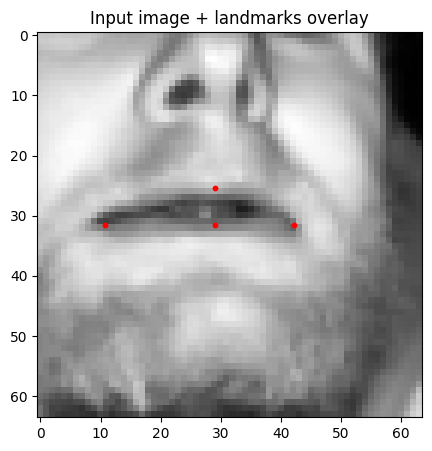

In [2]:
import sys
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

from src.dataset import MouthDataset
from src.transforms import build_train_transforms
from src.utils import load_config
import matplotlib.pyplot as plt

cfg = load_config("/inwdata2a/sudhanshu/Unet_training_script/configs/default.yaml")

# load just ONE sample — no training loop needed
dataset = MouthDataset(cfg['paths']['test_csv'], cfg, transform=build_train_transforms(cfg), is_train=True)
sample  = dataset[50]

img      = sample['image']        # tensor
landmarks = sample['landmarks']   # tensor
mask     = sample['mask']         # tensor
vis      = sample['visibility']   # tensor
path     = sample['img_path']       # string

# ── sanity checks ─────────────────────────────────────────────────────────────
print("image shape  :", img.shape)           # expect [1, 64, 64]
print("image range  :", img.min().item(), "to", img.max().item())  # expect ~[-1, 1] or [0, 1]
print("landmarks    :", landmarks.shape)     # expect [num_landmarks, 2]
print("landmark range:", landmarks.min().item(), "to", landmarks.max().item())  # expect [0, 1] normalized?
print("mask         :", mask)                # which landmarks are valid
print("visibility   :", vis)                 # blink/visibility flags
print("image path   :", path)                # sanity check for correct image loading

# ── visualize image + landmarks overlay ───────────────────────────────────────
plt.figure(figsize=(5, 5))
plt.imshow(img.squeeze(), cmap='gray')
# scale landmarks to pixel space for plotting
h, w = img.shape[1], img.shape[2]
lmk_px = landmarks.numpy() * [w, h]         # if landmarks are normalized 0-1
plt.scatter(lmk_px[:, 0], lmk_px[:, 1], c='red', s=10)
plt.title("Input image + landmarks overlay")
plt.show()

## Check the csv values

video_id  : 02a810f6-a62e-444a-a579-e938b5a278e7
frame_key : 29
face_bbox : 346,846,754,1295
mouth_bbox: 127,211,369,449
landmarks : 176.00,339.00;245.00,308.00;289.00,333.00;245.00,346.00


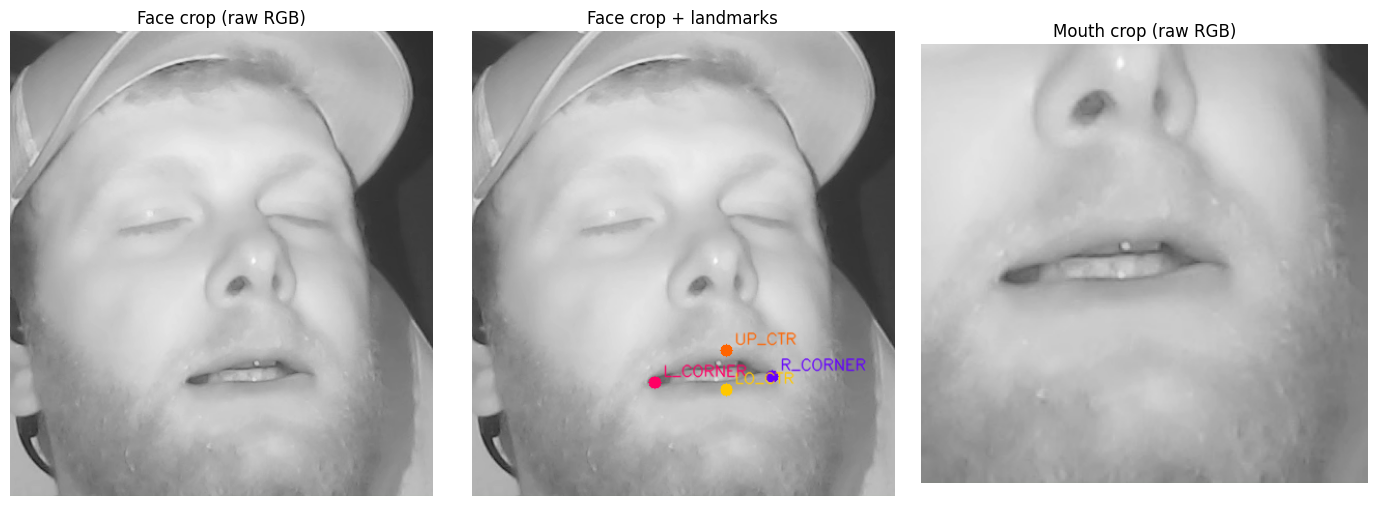

In [43]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt

CSV_PATH = "/inwdata2a/sudhanshu/mouth_keypoints/final_split/test.csv"
df = pd.read_csv(CSV_PATH)

# dataset[100] maps to valid_indices[100] — get that row directly
valid_indices = [
    i for i in range(len(df))
    if isinstance(df.iloc[i].landmarks_coordinates_inside_mouth_bbox, str)
    and "," in df.iloc[i].landmarks_coordinates_inside_mouth_bbox.strip()
]
row = df.iloc[valid_indices[100]]

print("video_id  :", row.video_id)
print("frame_key :", row.frame_key)
print("face_bbox :", row.face_bbox_dms)
print("mouth_bbox:", row.mouth_bbox_face)
print("landmarks :", row.landmarks_coordinates_inside_mouth_bbox)

# Raw crop — no CLAHE, no transforms
img = cv2.imread(row.path_to_dataset)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fx1, fy1, fx2, fy2 = map(int, row.face_bbox_dms.split(","))
face_crop = img_rgb[fy1:fy2, fx1:fx2]

mx1, my1, mx2, my2 = map(int, row.mouth_bbox_face.split(","))
mouth_crop_raw = face_crop[my1:my2, mx1:mx2]

# Parse and overlay landmarks on face crop
kps = [tuple(map(float, p.split(",")))
       for p in row.landmarks_coordinates_inside_mouth_bbox.split(";")]
kp_names  = ["L_CORNER", "UP_CTR", "R_CORNER", "LO_CTR"]
kp_colors = [(255,0,100), (255,100,0), (100,0,255), (255,200,0)]

face_vis = face_crop.copy()
for (x, y), name, col in zip(kps, kp_names, kp_colors):
    cv2.circle(face_vis, (int(x), int(y)), 6, col, -1)
    cv2.putText(face_vis, name, (int(x)+8, int(y)-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 1, cv2.LINE_AA)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(face_crop);    axes[0].set_title("Face crop (raw RGB)")
axes[1].imshow(face_vis);     axes[1].set_title("Face crop + landmarks")
axes[2].imshow(mouth_crop_raw); axes[2].set_title("Mouth crop (raw RGB)")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

## Check the Dyotana model and freeze it before using it as backbone 

In [3]:
# ── STANDALONE DEBUG CELL ─────────────────────────────────────────────────────
# Goal: test model loading + forward pass WITHOUT touching the training pipeline
# Run this in a notebook or as a plain python script independently

import sys
import torch

# ── Step 1: point to your source directories manually ─────────────────────────
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

# ── Step 2: import ONLY what you need — not the whole pipeline ─────────────────
from src.utils import load_unet_segmentation_model


import types

# ── Step 3: load the model ─────────────────────────────────────────────────────
frozen_backbone_model = load_unet_segmentation_model(
    "/inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt",
    device="cpu"
)

# ── Step 4: create a random input matching what the model expects ──────────────
# UnetUpSample_modified expects: [batch, channels, height, width]
# From config we know: single channel input, 64x64 image
dummy_input = torch.randn(1, 1, 64, 64)   # batch=1, channel=1, H=64, W=64

# ── Step 5: forward pass ───────────────────────────────────────────────────────
with torch.no_grad():
    output1, output2 = frozen_backbone_model(dummy_input)

# ── Step 6: verify output shapes make sense ────────────────────────────────────
print("output1 shape:", output1.shape)   # expected: [1, 64, 64]   — segmentation map
print("output2 shape:", output2.shape)   # expected: [1, 1, 64, 64] — blink probability
print("output1 unique values:", output1.unique())          # should be 0-3 (argmax of 4 classes)
print("output2 range:", output2.min().item(), "to", output2.max().item())  # should be 0-1 (sigmoid)
print("\n✅ Model loads and runs correctly")




### The general debugging framework — 4 questions to always ask
'''
1. WHAT do I want to test?
   → just the model? just a loss function? just a dataloader?

2. WHAT does it need to run?
   → trace only the direct dependencies, ignore everything else

3. WHAT goes in?
   → figure out the input shape/type and create a fake one with torch.randn / torch.zeros

4. WHAT should come out?
   → know the expected output shape and value range before you run it
      so you can immediately tell if something is wrong'''



---unet segmentor with upsample layers---
NUM PARAMS = 66761

[INFO] Loaded and set UnetUpSample_modified to train mode from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
[INFO] Total trainable params: 66761
output1 shape: torch.Size([1, 64, 64])
output2 shape: torch.Size([1, 1, 64, 64])
output1 unique values: tensor([0, 1, 2])
output2 range: 4.482759332353018e-18 to 0.9935790300369263

✅ Model loads and runs correctly


'\n1. WHAT do I want to test?\n   → just the model? just a loss function? just a dataloader?\n\n2. WHAT does it need to run?\n   → trace only the direct dependencies, ignore everything else\n\n3. WHAT goes in?\n   → figure out the input shape/type and create a fake one with torch.randn / torch.zeros\n\n4. WHAT should come out?\n   → know the expected output shape and value range before you run it\n      so you can immediately tell if something is wrong'

## Load the full model using the frozen backbone dyotana model

In [3]:
from models.unet_encoder_model import EyeLandmarkWithFrozenSegmentationBackbone

model=EyeLandmarkWithFrozenSegmentationBackbone(
    segmentation_model=frozen_backbone_model
)

dummy_input = torch.randn(1, 1, 64, 64)   # batch=1, channel=1, H=64, W=64
output = model(dummy_input)

for outputs in output:
    print(outputs)

print("heatmap shape:", output["heatmaps"].shape)   # expected: [1, num_landmarks, 64, 64]
print("coords shape:", output["coords"].shape)   


[INFO] Frozen segmentation model (all params set to requires_grad=False)
[INFO] Created EyeLandmarkWithFrozenSegmentationBackbone:
  - segmentation model params: 66761
  - Trainable heatmap head params: 14020
heatmaps
coords
output1
output2
heatmap shape: torch.Size([1, 4, 64, 64])
coords shape: torch.Size([1, 4, 2])


## Debug NaN in eye_visibility

In [8]:
import pandas as pd

df= pd.read_csv("/inwdata2a/sudhanshu/Unet_training_script/data-and-labels/final_split/train.csv")
print(df['eye_visibility'].isna().sum())
print(df['eye_visibility'].unique())


nan_rows= df[df['eye_visibility'].isna()]
print(nan_rows)

0
[ True False]
Empty DataFrame
Columns: [video_id, frame_key, eye_side, eye_visibility, path_to_dataset, eye_bbox_face, landmarks_coordinates_inside_eye_bbox]
Index: []


In [1]:
MouthLandmarkModel

NameError: name 'MouthLandmarkModel' is not defined

In [2]:
import sys
import torch

# ── Step 1: point to your source directories manually ─────────────────────────
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

from models.unet_encoder_model import MouthLandmarkModel

from src.utils import (
    load_unet_segmentation_model
)

# ── Model ─────────────────────────────────────────────────────────────────
pretrain_path = "/inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt"
print(f"[INFO] Loading backbone (end-to-end trainable) from: {pretrain_path}")

# Load backbone weights — train mode, gradients enabled
backbone = load_unet_segmentation_model(pretrain_path)

# Wrap in fully trainable mouth model
model = MouthLandmarkModel(
    backbone      = backbone,
    num_landmarks = 4
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Trainable params: {trainable}")   # should be ~51k+ now, not 14k



dummy_input = torch.randn(1, 1, 128, 128)   # batch=1, channel=1, H=128, W=128
output = model(dummy_input)

for outputs in output:
    print(outputs)

print("heatmap shape:", output["heatmaps"].shape)   # expected: [1, num_landmarks, 128, 128]
print("coords shape:", output["coords"].shape)   


[INFO] Loading backbone (end-to-end trainable) from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
---unet segmentor with upsample layers---
NUM PARAMS = 66761

[INFO] Loaded and set UnetUpSample_modified to train mode from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
[INFO] Total trainable params: 66761
[INFO] MouthLandmarkModel created
[INFO] Total params: 80781  |  Trainable: 80781
[INFO] Trainable params: 80781
heatmaps
coords
heatmap shape: torch.Size([1, 4, 128, 128])
coords shape: torch.Size([1, 4, 2])


## Check the model architecture

In [6]:
from torchinfo import summary

import sys
import torch

# ── Step 1: point to your source directories manually ─────────────────────────
sys.path.insert(0, "/inwdata2a/sudhanshu/Unet_training_script")

from models.unet_encoder_model import MouthLandmarkModel

from src.utils import (
    load_unet_segmentation_model
)

# ── Model ─────────────────────────────────────────────────────────────────
pretrain_path = "/inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt"
print(f"[INFO] Loading backbone (end-to-end trainable) from: {pretrain_path}")

# Load backbone weights — train mode, gradients enabled
backbone = load_unet_segmentation_model(pretrain_path)

# Wrap in fully trainable mouth model
model = MouthLandmarkModel(
    backbone      = backbone,
    num_landmarks = 4
)

summary(model, input_size=(1, 1, 128, 128))  # adjust H, W to your crop size

[INFO] Loading backbone (end-to-end trainable) from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
---unet segmentor with upsample layers---
NUM PARAMS = 66761

[INFO] Loaded and set UnetUpSample_modified to train mode from: /inwdata2a/sudhanshu/landmarks_only_training/outputs_landmarks_unet/dyotana-model.pt
[INFO] Total trainable params: 66761
[INFO] MouthLandmarkModel created
[INFO] Total params: 80781  |  Trainable: 80781


Layer (type:depth-idx)                   Output Shape              Param #
MouthLandmarkModel                       [1, 4, 2]                 --
├─UnetUpSample_modified: 1-1             --                        1,205
│    └─UnetEnc: 2-1                      [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                  [1, 16, 128, 128]         160
│    │    └─BatchNorm2d: 3-2             [1, 16, 128, 128]         32
│    │    └─MaxPool2d: 3-3               [1, 16, 64, 64]           --
│    └─UnetEnc: 2-2                      [1, 16, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 16, 64, 64]           2,320
│    │    └─BatchNorm2d: 3-5             [1, 16, 64, 64]           32
│    │    └─MaxPool2d: 3-6               [1, 16, 32, 32]           --
│    └─UnetEnc: 2-3                      [1, 24, 32, 32]           --
│    │    └─Conv2d: 3-7                  [1, 24, 32, 32]           3,480
│    │    └─BatchNorm2d: 3-8             [1, 24, 32, 32]           48
│    

In [4]:
print(model)

MouthLandmarkModel(
  (backbone): UnetUpSample_modified(
    (enc64): UnetEnc(
      (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (enc32): UnetEnc(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (enc16): UnetEnc(
      (conv1): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (enc8): UnetEnc(
      (conv1): Conv2d(24, 32, kernel_size=(3, 3), 